<a href="https://colab.research.google.com/github/StrelecTanya/Test_task/blob/main/Biocad_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Импорт необходимых библиотек

# Для подготовки данных
import pandas as pd
import numpy as np
import re

# Для обучения модели
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Для визуализации данных
import matplotlib.pyplot as plt

In [2]:
# Загрузка данных
!wget https://life.bsc.es/pid/skempi2/database/download/skempi_v2.csv

--2025-05-03 17:16:39--  https://life.bsc.es/pid/skempi2/database/download/skempi_v2.csv
Resolving life.bsc.es (life.bsc.es)... 84.88.52.107
Connecting to life.bsc.es (life.bsc.es)|84.88.52.107|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1602208 (1.5M) [text/csv]
Saving to: ‘skempi_v2.csv’

skempi_v2.csv       100%[===================>]   1.53M  2.93MB/s    in 0.5s    

2025-05-03 17:16:41 (2.93 MB/s) - ‘skempi_v2.csv’ saved [1602208/1602208]



In [3]:
# Импорт данных
data = pd.read_csv('skempi_v2.csv', sep=';')

In [4]:
data.columns

Index(['#Pdb', 'Mutation(s)_PDB', 'Mutation(s)_cleaned',
       'iMutation_Location(s)', 'Hold_out_type', 'Hold_out_proteins',
       'Affinity_mut (M)', 'Affinity_mut_parsed', 'Affinity_wt (M)',
       'Affinity_wt_parsed', 'Reference', 'Protein 1', 'Protein 2',
       'Temperature', 'kon_mut (M^(-1)s^(-1))', 'kon_mut_parsed',
       'kon_wt (M^(-1)s^(-1))', 'kon_wt_parsed', 'koff_mut (s^(-1))',
       'koff_mut_parsed', 'koff_wt (s^(-1))', 'koff_wt_parsed',
       'dH_mut (kcal mol^(-1))', 'dH_wt (kcal mol^(-1))',
       'dS_mut (cal mol^(-1) K^(-1))', 'dS_wt (cal mol^(-1) K^(-1))', 'Notes',
       'Method', 'SKEMPI version'],
      dtype='object')

Мы видим, что свободной энергии связывания здесь нет в явном виде, поэтому вычислим ее с помощью аффинности:

                                               ΔG = RT * ln(Aff_mut / Aff_wt)
где:

R - газовая постоянная,

T — температура,

Aff_mut, Aff_wt - аффинность мутантного белка и белка без мутации (wild type).

Все вычисляемые значения представлены в виде строк, поэтому преобразуем их в числовой формат

In [5]:
data['Temperature'] = pd.to_numeric(data['Temperature'], errors='coerce')
data['Affinity_mut (M)'] = pd.to_numeric(data['Affinity_mut (M)'], errors='coerce')
data['Affinity_wt (M)'] = pd.to_numeric(data['Affinity_wt (M)'], errors='coerce')

In [6]:
R = 1.987e-3  # Газовая постоянная в kcal/(mol·K)
data['delta_G'] = R * data['Temperature'] * np.log(data['Affinity_mut (M)'] / data['Affinity_wt (M)'])

In [7]:
data['delta_G'].describe()

,delta_G
count,4432.000000
mean,1.249633
std,2.256307
min,-12.221147
25%,0.010084
50%,0.725748
75%,2.200013
max,12.221147


In [24]:
#Статистика по пропущенным значениям в каждой колонке
data.isna().sum()

,0
#Pdb,0
Mutation(s)_PDB,0
Mutation(s)_cleaned,0
iMutation_Location(s),0
Hold_out_type,3774
Hold_out_proteins,0
Affinity_mut (M),445
Affinity_mut_parsed,285
Affinity_wt (M),43
Affinity_wt_parsed,2


Для предскаазния изменения свободной энергии связывания буду использовать следующие признаки:


1.   Mutation(s)_PDB - информация о том, какая замена произошла в белке (Исходная АК/ тип замены / позиция замены / Новая АК)

2.   iMutation_Location(s) - локализация в структуре белка (COR, RIM, SUP, SUR, INT и тд)

3. Метод эксперимента

Еще можно было бы использовать термодинамические и кинетические параметры (dH_mut, dH_wt (изменение энтальпии), dS_mut, dS_wt (изменение энтропии), kon_mut, koff_mut (константы скорости)), но к сожалению в них слишком много пропущенных значений.

Перед тем, как предсказывать изменение свободной энергии надо правильно закодировать признаки.



Начнем с Mutation(s)_PDB, которую следует разделить на 3 столбца - изначальная АК, цепь, позиция, АК в замене

In [8]:
import pandas as pd
import re
import numpy as np

def parse_mutations(row):
    """Функция для разбора строк с мутациями и сопоставления с локализацией"""
    mutations = []
    if pd.isna(row['Mutation(s)_PDB']):
        return mutations

    # Разделяем мутации по запятым
    mutation_list = row['Mutation(s)_PDB'].split(',')

    # Разделяем локализации по запятым (если есть)
    locations = str(row['iMutation_Location(s)']).split(',') if pd.notna(row['iMutation_Location(s)']) else []

    # Разделяем ddG (если нужно)
    ddG_values = str(row['delta_G']).split(',') if pd.notna(row['delta_G']) else []

    for i, mut in enumerate(mutation_list):
        parts = re.split('(\d+)', mut)
        if len(parts) >= 3:
            if ':' in parts[0]:
                chain = parts[0].split(':')[0]
                old_aa = parts[0].split(':')[1][1]
            else:
                chain = parts[0][0]
                old_aa = parts[0][1]

            pos = parts[1]
            new_aa = parts[2][:3]

            # Берем соответствующую локализацию и ddG (если есть)
            loc = locations[i] if i < len(locations) else None
            ddG = ddG_values[i] if i < len(ddG_values) else None

            mutations.append({
                'WD_AC': old_aa,
                'Location_of_mutation': pos,
                'New_AC': new_aa,
                'Mutation_Location': loc,
                'ddG': ddG
            })

    return mutations

# Применяем функцию к каждой строке
parsed_data = data.apply(parse_mutations, axis=1)

# Создаем новый датафрейм с развернутыми мутациями
expanded_data = []
for idx, mutations in enumerate(parsed_data):
    for mut in mutations:
        mut['original_row_index'] = idx  # Сохраняем ссылку на исходную строку
        expanded_data.append(mut)

# Создаем итоговый датафрейм
result_df = pd.DataFrame(expanded_data)

# Объединяем с исходными данными (если нужно)
final_df = pd.merge(
    data.reset_index(),
    result_df,
    left_on='index',
    right_on='original_row_index',
    how='right'
).drop(columns=['index', 'original_row_index'])

In [29]:
df = final_df[['Method', 'WD_AC', 'Location_of_mutation', 'New_AC', 'Mutation_Location', 'ddG']].dropna()

In [30]:
df['Location_of_mutation'] = df['Location_of_mutation'].astype(int)
df['ddG'] = df['ddG'].astype(float)

Для предсказывания будем использовать градиентный бустинг. Он не склонен к переобучению и хорошо себя показывает при работе с табличными данными.

RMSE: 1.6950949024660582
R2 Score: 0.4579888099790814


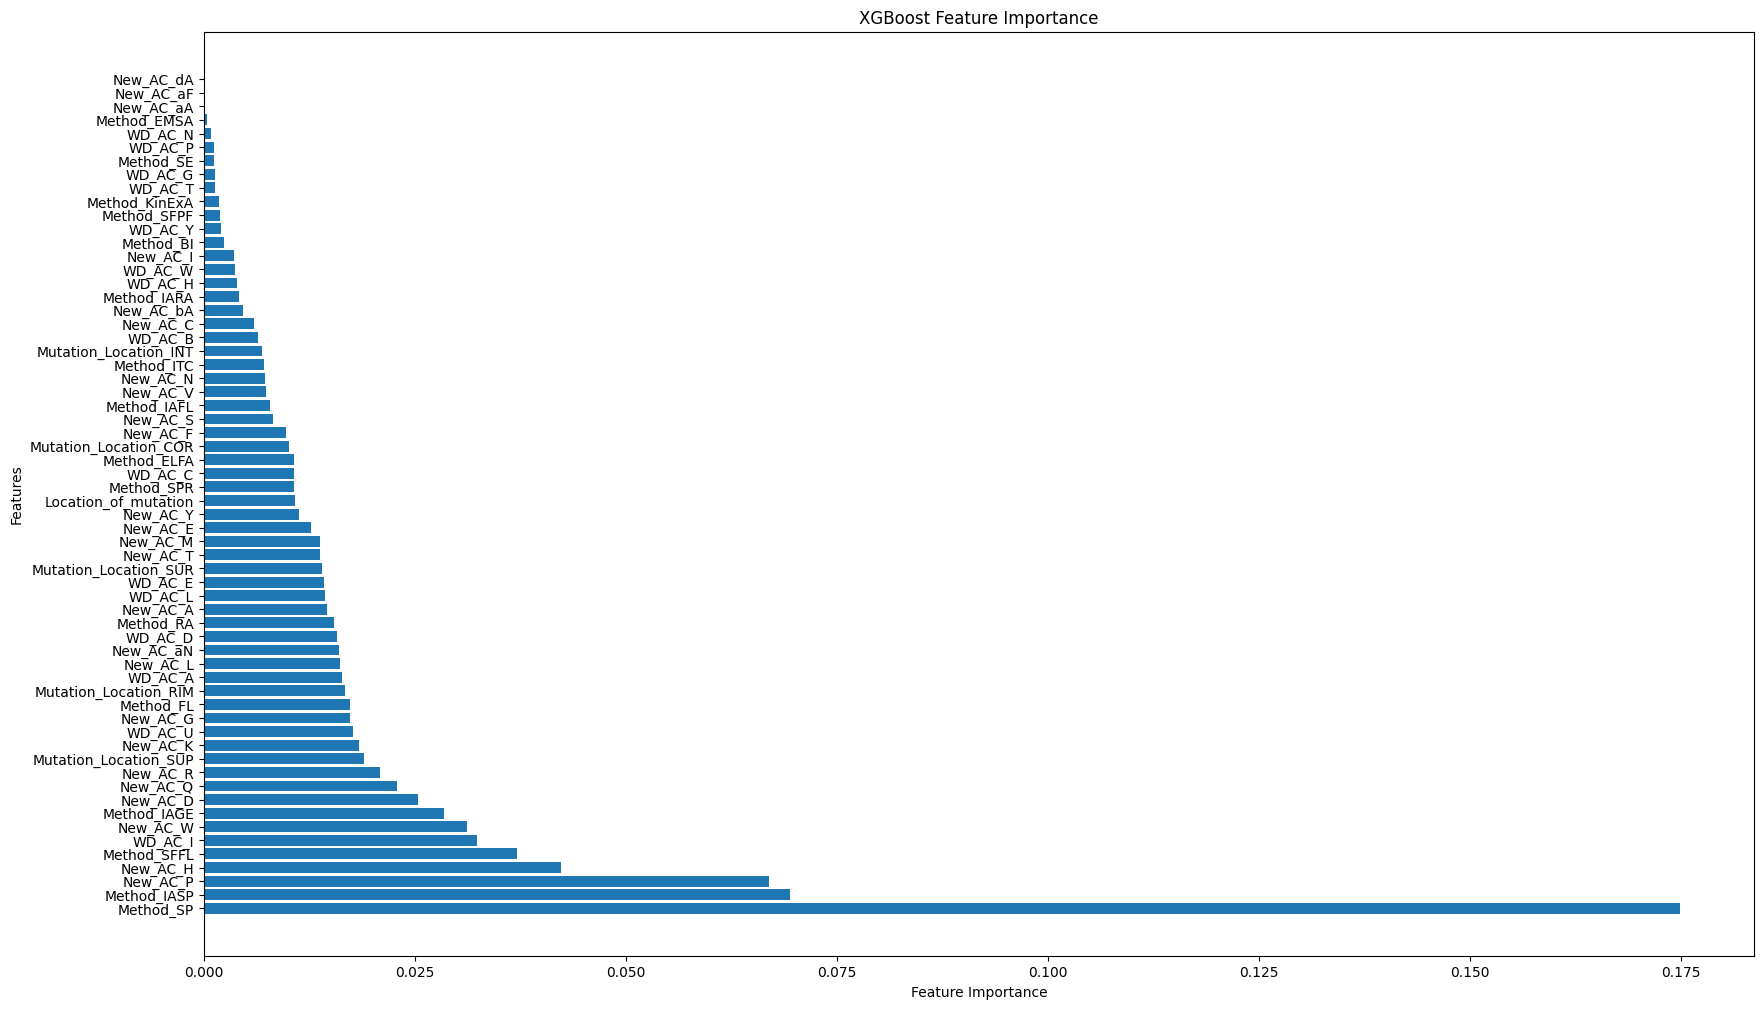

In [31]:
# Использование данных в задаче регрессии

# 1. Предобработка данных
# Кодируем категориальные признаки
categorical_features = ['Method', 'WD_AC', 'New_AC', 'Mutation_Location']
numeric_features = ['Location_of_mutation']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 2. Разделение данных
X = df.drop(['ddG'], axis=1)
y = df['ddG']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Создание модели
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=100,
        learning_rate=0.1,
        max_depth=10,
        random_state=42
    ))
])

# 4. Обучение модели
model.fit(X_train, y_train)

# 5. Оценка модели
y_pred = model.predict(X_test)
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

# 6. Визуализация важности признаков
# Сначала получим имена всех признаков после OneHotEncoding
feature_names = (numeric_features +
                list(model.named_steps['preprocessor']
                    .named_transformers_['cat']
                    .get_feature_names_out(categorical_features)))

# Теперь получим важность признаков
importance = model.named_steps['regressor'].feature_importances_

# Создаем DataFrame для визуализации
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
importance_df = importance_df.sort_values('Importance', ascending=False)

# Визуализация
plt.figure(figsize=(20, 12))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('XGBoost Feature Importance')
plt.show()

**Вывод:** Модель регрессии улавливает общие тенденции, но недостаточно точна для предсказания абсолютных значений ΔΔG. Возможные причины:

*   Нехватка ключевых признаков, описывающих энергетику (например, параметры растворимости, водородные связи).

*   Выбросы в данных (редкие мутации с очень большими ΔΔG).

*   Нелинейные зависимости, которые не учитывает XGBoost с текущими параметрами.

In [33]:
# Использование в задаче классификации - предсказание знака изменения свободной энергии связывания

# 1. Преобразуем целевую переменную в бинарный признак (1 если ddG > 0, иначе 0)
df['ddG_sign'] = np.where(df['ddG'] > 0, 1, 0)

# 2. Предобработка данных
categorical_features = ['Method', 'WD_AC', 'New_AC', 'Mutation_Location']
numeric_features = ['Location_of_mutation']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 3. Разделение данных
X = df.drop(['ddG', 'ddG_sign'], axis=1)
y = df['ddG_sign']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Создание модели классификации
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        objective='binary:logistic',
        n_estimators=150,
        learning_rate=0.05,
        max_depth=5,
        scale_pos_weight=np.sum(y == 0) / np.sum(y == 1),  # Балансировка классов
        random_state=42
    ))
])

# 5. Обучение модели
model.fit(X_train, y_train)

# 6. Оценка модели
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.73
F1 Score: 0.81
Confusion Matrix:
[[130  90]
 [151 516]]


In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

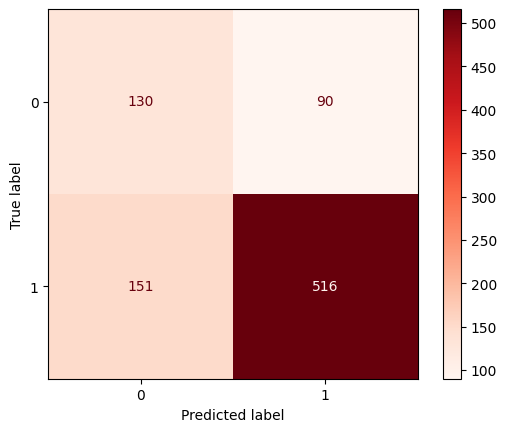

In [35]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred)
)

disp.plot(cmap='Reds')
plt.show()

По confusion_matrix видно, что модель предсказывает один класс лучше (точнее) другого. Скорее всего это означает, что есть дисбаланс классов.

In [36]:
df['ddG_sign'].value_counts()

,count
ddG_sign,
1,3331
0,1101


Видно, что класс 1 присутсвует в нашей выборке в 3 раза больше, чем класс 0. Поэтому для оценки работы модели воспользуемся метриками, которые устойчивы к дисбалансу - сбалансированная точность, коэффиицент корреляции мэтьюса и pr_auc_score.

In [37]:
from sklearn.metrics import balanced_accuracy_score, matthews_corrcoef, precision_recall_curve, auc

print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.2f}")
print(f"MCC: {matthews_corrcoef(y_test, y_pred):.2f}")

# Вычисляем Precision-Recall кривую
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

# Рассчитываем площадь под кривой (PR-AUC)
pr_auc = auc(recall, precision)
print(f"PR_AUC: {pr_auc:.2f}")

Balanced accuracy: 0.68
MCC: 0.34
PR_AUC: 0.90


**Выводы:** Модель эффективно предсказывает знак изменения энергии Гиббса, особенно для положительных значений (ухудшение связывания), что подтверждается высоким PR-AUC. Однако умеренные значения Balanced Accuracy и MCC. Для улучшения предсказаний возможно стоит добавить признаки, влияющие на знак ΔΔG (например, физико-химические свойства аминокислот в позиции мутации).